In [5]:
import os

folder_path = 'benchmarks/results' 
files = os.listdir(folder_path)
print(files)

['20260318_145955', '20260314_195539', '20260316_020327', '20260318_164756', '20260312_103401']


In [6]:
import pandas as pd
import glob

# csv_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
# print("CSV files found:", csv_files)

csv_files = ['benchmarks/results/20260318_145955/summary.csv', 'benchmarks/results/20260318_164756/summary.csv']

combined_df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

In [7]:
combined_df = combined_df.drop(columns=['batch_size', 'block_size', 'decode_mode', 'gen_length', 'model_path', 'offload_dir',
                                        'prompt_mode', 'raw_stdout', 'repetitions', 'target_context_len', 'threshold',
                                        'trace_dir', 'use_torch_profiler', 'warmup'])
combined_df

,do_compile,max_mem_alloc_mb,max_mem_reserved_mb,model_key,per_token_time_ms,prompt_len,run_type,tokens_per_s,total_time_s
0,True,3942.153320,4530.0,qwen,48.107190,128,baseline,20.786914,6.157720
1,True,3942.153320,4530.0,qwen,60.924656,128,profiled,16.413716,7.798356
2,True,3971.157715,4582.0,qwen,49.770664,256,baseline,20.092157,6.370645
3,True,3971.157715,4582.0,qwen,61.493253,256,profiled,16.261947,7.871136
4,True,4031.433594,4526.0,qwen,53.516373,512,baseline,18.685870,6.850096
5,True,4031.433594,4526.0,qwen,62.249069,512,profiled,16.064497,7.967881
6,True,4145.182617,4472.0,qwen,59.833819,1024,baseline,16.712956,7.658729
7,True,4145.182617,4472.0,qwen,64.010170,1024,profiled,15.622518,8.193302
8,True,4377.215820,4472.0,qwen,73.723249,2048,baseline,13.564242,9.436576
9,True,4377.215820,4472.0,qwen,75.203079,2048,profiled,13.297328,9.625994


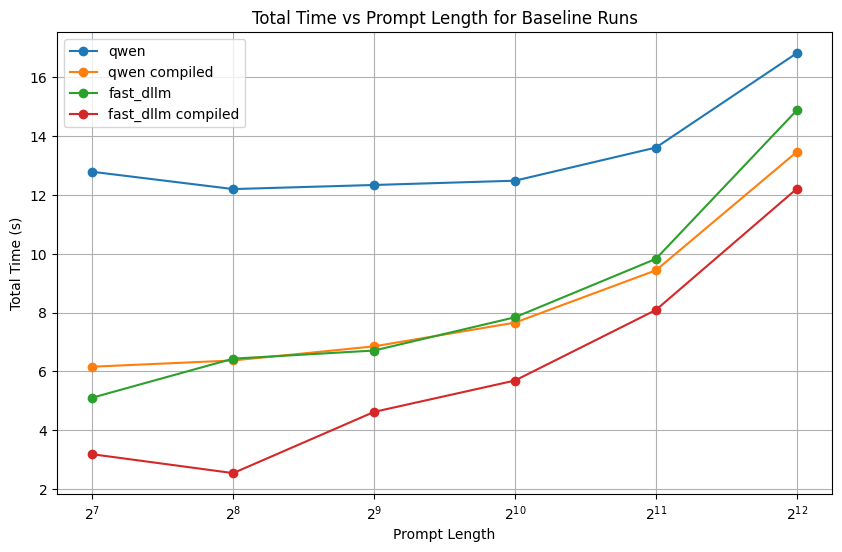

In [8]:
import matplotlib.pyplot as plt

df_baseline = combined_df[combined_df['run_type'] == 'baseline']

fig, ax = plt.subplots(figsize=(10, 6))

for model in ['qwen', 'fast_dllm']:
    for compile_val in [False, True]:
        subset = df_baseline[(df_baseline['model_key'] == model) & (df_baseline['do_compile'] == compile_val)]
        label = f"{model}" if not compile_val else f"{model} compiled"
        plt.plot(subset['prompt_len'], subset['total_time_s'], marker='o', label=label)
ax.set_xscale("log", base=2)
plt.xlabel('Prompt Length')
plt.ylabel('Total Time (s)')
plt.title('Total Time vs Prompt Length for Baseline Runs')
plt.legend()
plt.grid(True)
plt.show()